# CIFAR-10 FCN
The goal of this model is to use CIFAR-10 to solve image classification problems.  
This model uses Fully Convolutional Networks (FCN).

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
from tensorflow.keras.datasets import cifar10

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

C:\Users\Omistaja\anaconda3\envs\keras\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


tensorflow


## Building the model
I tried a few different configurations for the model, increasing the first layer's neurons to 512, kernel regularizer and dropout.  
I found that these mostly lowered the training and performance of the model, and settled on BatchNormalization.

In [63]:
from keras.layers import Input, Flatten, Dense, BatchNormalization

model = keras.models.Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dense(10, activation="softmax")
])

In [64]:
from tensorflow.keras.utils import to_categorical
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

x_train, x_test = x_train / 255, x_test / 255

print(x_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 10)


Here I also tried tweaking the learning rate of the model, but found that every change seemingly made performance worse.  
Because of that, I opted to not change the default values.

In [65]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [66]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [67]:
history = model.fit(x_train, y_train, batch_size=32, epochs=20, validation_split=0.2, callbacks=[early_stop])

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3705 - loss: 1.7697 - val_accuracy: 0.3306 - val_loss: 1.8880
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4268 - loss: 1.6019 - val_accuracy: 0.3733 - val_loss: 1.7799
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4551 - loss: 1.5208 - val_accuracy: 0.4231 - val_loss: 1.6781
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4737 - loss: 1.4722 - val_accuracy: 0.4335 - val_loss: 1.6352
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4989 - loss: 1.4102 - val_accuracy: 0.4447 - val_loss: 1.6016
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5089 - loss: 1.3720 - val_accuracy: 0.4652 - val_loss: 1.5169
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5230 - loss: 1.3431 - val_accuracy: 0.4482 - val_loss: 1.5785
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5359 - loss: 1.3058 - 

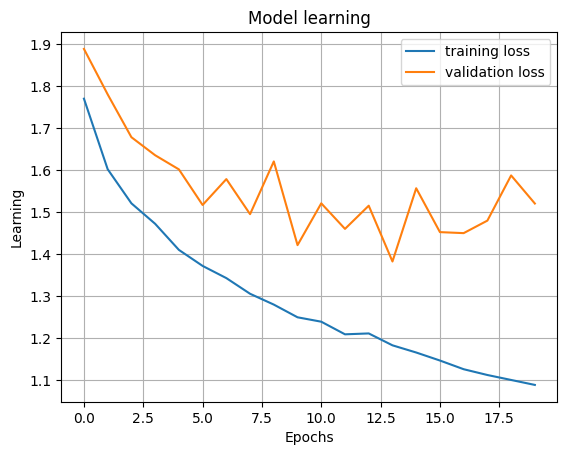

In [70]:
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("Model learning")
plt.xlabel('Epochs')
plt.ylabel('Learning')
plt.legend()
plt.grid()
plt.show()

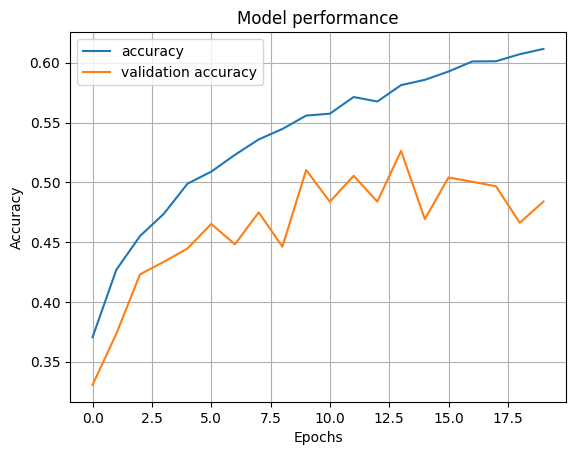

In [71]:
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.title("Model performance")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

## Example images
![Raven image](img/raven.jpg) ✔ This picture depicts a raven and is correctly identified as a bird  

![Ostrich image](img/ostrich.jpg) ❌ This picture depicts an ostrich and is incorrectly labeled as a horse  

![Zebra image](img/zebra.jpg) ✔ This picture depicts a zebra and is correctly identified as a horse  

![Stealth jet image](img/stealth_jet.jpg) ✔ This picture depicts a stealth jet and is correctly identified as an airplane  

![Monster truck image](img/monster_truck.jpg) 🔹 This picture depicts a monster truck and is generalized as an automobile

In [81]:
# img preprocessing and loading from geeksforgeeks / ChatGPT.
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array

def load_and_process_image(name):
    img = load_img(f'img/{name}')
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

In [91]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

def predict_image(img_array, name):
    predictions = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(predictions[0])
    predicted_label = class_names[predicted_index]
    print(f"Image {name} is predicted to be {predicted_label}")
    return predictions[0]

In [92]:
probs1 = predict_image(load_and_process_image('raven.jpg'), 'Raven')
probs2 = predict_image(load_and_process_image('ostrich.jpg'), 'Ostrich')
probs3 = predict_image(load_and_process_image('zebra.jpg'), 'Zebra')
probs4 = predict_image(load_and_process_image('stealth_jet.jpg'), 'Stealth Jet')
probs5 = predict_image(load_and_process_image('monster_truck.jpg'), 'Monster Truck')

Image Raven is predicted to be bird
Image Ostrich is predicted to be horse
Image Zebra is predicted to be horse
Image Stealth Jet is predicted to be airplane
Image Monster Truck is predicted to be automobile


C:\Users\Omistaja\AppData\Local\Temp\ipykernel_14216\1195392716.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45)
C:\Users\Omistaja\AppData\Local\Temp\ipykernel_14216\1195392716.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45)
C:\Users\Omistaja\AppData\Local\Temp\ipykernel_14216\1195392716.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45)
C:\Users\Omistaja\AppData\Local\Temp\ipykernel_14216\1195392716.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45)
C:\Users\Omistaj

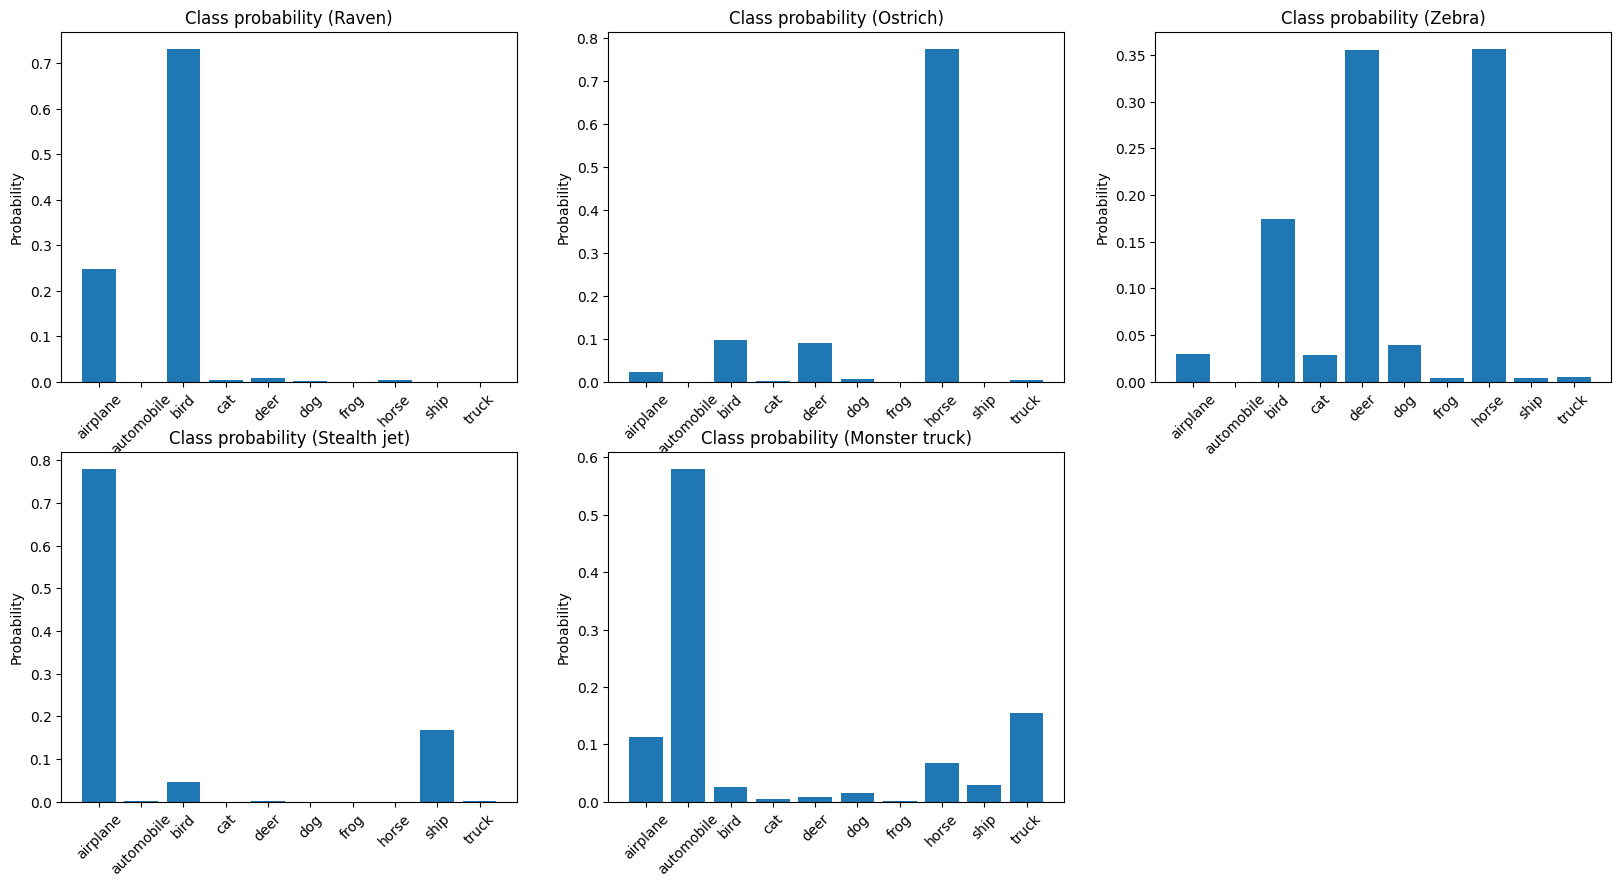

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [112]:
import math
all_probs = [probs1, probs2, probs3, probs4, probs5]
all_names = ["Raven", "Ostrich", "Zebra", "Stealth jet", "Monster truck"]

n_items = len(all_probs)
n_cols = 3
n_rows = math.ceil(n_items / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, probs in enumerate(all_probs):
    plt.figure()
    ax = axes[i]
    ax.bar(class_names, probs)
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_ylabel("Probability")
    ax.set_title(f"Class probability ({all_names[i]})")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()